In [71]:
from pathlib import Path
import re
import csv
import gzip
import ast
import pandas as pd
from functools import lru_cache

PROJECT_ROOT = Path("..").resolve()
ASSEMBLIES_ROOT = PROJECT_ROOT / "data" / "assemblies_spades" / "final_run"
OUT_TSV = PROJECT_ROOT / "reports" / "final_run" / "eval_final_all_t0p5.tsv"

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("ASSEMBLIES_ROOT=", ASSEMBLIES_ROOT)
print("OUT_TSV        =", OUT_TSV)

PROJECT_ROOT   = /Users/yvonnelin/Desktop/mitochime
ASSEMBLIES_ROOT= /Users/yvonnelin/Desktop/mitochime/data/assemblies_spades/final_run
OUT_TSV        = /Users/yvonnelin/Desktop/mitochime/reports/final_run/eval_final_all_t0p5.tsv


In [72]:
def read_text(p: Path) -> str:
    try:
        return p.read_text(errors="ignore")
    except Exception:
        return ""

def fasta_contig_lengths(fa_path: Path):
    lens = []
    cur = 0
    for line in fa_path.read_text(errors="ignore").splitlines():
        if line.startswith(">"):
            if cur > 0:
                lens.append(cur)
                cur = 0
        else:
            cur += len(line.strip())
    if cur > 0:
        lens.append(cur)
    return lens

@lru_cache(maxsize=None)
def count_fastq_reads(fq_path_str: str):
    fq_path = Path(fq_path_str)
    if not fq_path.exists():
        return None
    opener = gzip.open if fq_path.suffix == ".gz" else open
    n_lines = 0
    with opener(fq_path, "rt", errors="ignore") as f:
        for _ in f:
            n_lines += 1
    return n_lines // 4 if n_lines else 0

def parse_spades_fastqs(spades_dir: Path):
    candidates = [
        spades_dir / "spades.log",
        spades_dir / "spades.log.txt",
        spades_dir / "params.txt",
    ]
    txt = ""
    for c in candidates:
        if c.exists():
            txt += "\n" + read_text(c)

    left_path = None
    right_path = None

    m_left = re.search(r"left reads:\s*(\[[^\n]+\])", txt, flags=re.I)
    m_right = re.search(r"right reads:\s*(\[[^\n]+\])", txt, flags=re.I)

    if m_left:
        try:
            vals = ast.literal_eval(m_left.group(1))
            if isinstance(vals, list) and vals:
                left_path = vals[0]
        except Exception:
            pass

    if m_right:
        try:
            vals = ast.literal_eval(m_right.group(1))
            if isinstance(vals, list) and vals:
                right_path = vals[0]
        except Exception:
            pass

    reads_pairs_used = count_fastq_reads(left_path) if left_path else None

    return {
        "left_reads_path": left_path,
        "right_reads_path": right_path,
        "reads_pairs_used": reads_pairs_used,
    }

In [73]:
def parse_folder_name(folder: str):
    """
    Returns:
      dataset, model, thresh

    Supports old GB/CNN naming and new BIGRU naming.
    """

    # old scheme: 10K_final_10_unfiltered / gb / cnn_fixedep25
    m = re.match(r"^(3200|10K|20K)_final_(\d+)_(.+)$", folder, flags=re.I)
    if m:
        read_level = m.group(1).upper()
        chim = m.group(2)
        suffix = m.group(3).lower()

        dataset = f"{read_level}_final_{chim}"

        if suffix == "unfiltered":
            return dataset, "UNFILTERED", "NA"
        if suffix.startswith("gb"):
            m_t = re.search(r"t([0-9]+p?[0-9]*)", suffix)
            thresh = m_t.group(1).replace("p", ".") if m_t else "0.5"
            return dataset, "GB", thresh
        if suffix.startswith("cnn"):
            m_t = re.search(r"t([0-9]+p?[0-9]*)", suffix)
            thresh = m_t.group(1).replace("p", ".") if m_t else "0.5"
            return dataset, "CNN_fixedep25", thresh

        return None, None, None

    # new bigru scheme: bigru_10k_10_bigru_filtered / bigru_10k_10_unfiltered
    m = re.match(r"^bigru_(10k|20k|3k)_(\d+)_(bigru_filtered|unfiltered)$", folder, flags=re.I)
    if m:
        rl_raw = m.group(1).lower()
        chim = m.group(2)
        suffix = m.group(3).lower()

        rl_map = {"3k": "3200", "10k": "10K", "20k": "20K"}
        read_level = rl_map[rl_raw]
        dataset = f"{read_level}_final_{chim}"

        if suffix == "unfiltered":
            return dataset, "UNFILTERED", "NA"
        if suffix == "bigru_filtered":
            return dataset, "BIGRU", "0.5"

    return None, None, None

In [74]:
rows = []

for run_root in sorted([p for p in ASSEMBLIES_ROOT.iterdir() if p.is_dir()]):
    dataset, model, thresh = parse_folder_name(run_root.name)
    if dataset is None:
        continue

    contig_hits = list(run_root.rglob("contigs.fasta"))
    if not contig_hits:
        rows.append({
            "dataset": dataset,
            "model": model,
            "thresh": thresh,
            "reads_out": None,
            "spades_contigs": None,
            "spades_total_len": None,
            "spades_max_len": None,
            "contigs_path": None,
            "run_root": str(run_root),
        })
        continue

    contigs = contig_hits[0]
    lens = fasta_contig_lengths(contigs)
    spades_contigs = len(lens)
    spades_total_len = sum(lens) if lens else 0
    spades_max_len = max(lens) if lens else None

    spades_dir = contigs.parent
    log_info = parse_spades_fastqs(spades_dir)
    reads_out = log_info["reads_pairs_used"]

    rows.append({
        "dataset": dataset,
        "model": model,
        "thresh": thresh,
        "reads_out": reads_out,
        "spades_contigs": spades_contigs,
        "spades_total_len": spades_total_len,
        "spades_max_len": spades_max_len,
        "contigs_path": str(contigs.relative_to(PROJECT_ROOT)),
        "run_root": str(run_root),
    })

raw_df = pd.DataFrame(rows).sort_values(["dataset", "model"]).reset_index(drop=True)
raw_df.head(20)

,dataset,model,thresh,reads_out,spades_contigs,spades_total_len,spades_max_len,contigs_path,run_root
0,10K_final_10,BIGRU,0.5,7938,1,16614,16614,data/assemblies_spades/final_run/bigru_10k_10_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
1,10K_final_10,CNN_fixedep25,0.5,7847,1,16693,16693,data/assemblies_spades/final_run/10K_final_10_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
2,10K_final_10,GB,0.5,9530,1,16614,16614,data/assemblies_spades/final_run/10K_final_10_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
3,10K_final_10,UNFILTERED,NA,10000,1,16704,16704,data/assemblies_spades/final_run/10K_final_10_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
4,10K_final_10,UNFILTERED,NA,10000,1,16704,16704,data/assemblies_spades/final_run/bigru_10k_10_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
5,10K_final_15,BIGRU,0.5,7521,1,16611,16611,data/assemblies_spades/final_run/bigru_10k_15_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
6,10K_final_15,CNN_fixedep25,0.5,7595,1,16611,16611,data/assemblies_spades/final_run/10K_final_15_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
7,10K_final_15,GB,0.5,9333,1,16642,16642,data/assemblies_spades/final_run/10K_final_15_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
8,10K_final_15,UNFILTERED,NA,10000,1,16735,16735,data/assemblies_spades/final_run/10K_final_15_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
9,10K_final_15,UNFILTERED,NA,10000,1,16735,16735,data/assemblies_spades/final_run/bigru_10k_15_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...


In [75]:
raw_df[["dataset", "model"]].value_counts().sort_index()

dataset        model        
10K_final_10   BIGRU            1
               CNN_fixedep25    1
               GB               1
               UNFILTERED       2
10K_final_15   BIGRU            1
               CNN_fixedep25    1
               GB               1
               UNFILTERED       2
10K_final_5    BIGRU            1
               CNN_fixedep25    1
               GB               1
               UNFILTERED       2
10K_final_50   BIGRU            1
               CNN_fixedep25    1
               GB               1
               UNFILTERED       2
20K_final_10   BIGRU            1
               CNN_fixedep25    1
               GB               1
               UNFILTERED       2
20K_final_15   BIGRU            1
               CNN_fixedep25    1
               GB               1
               UNFILTERED       2
20K_final_5    BIGRU            1
               CNN_fixedep25    1
               GB               1
               UNFILTERED       2
20K_final_50   BIGR

In [76]:
df = (
    raw_df.sort_values(
        ["dataset", "model", "reads_out", "spades_total_len"],
        ascending=[True, True, False, False]
    )
    .drop_duplicates(subset=["dataset", "model"], keep="first")
    .reset_index(drop=True)
)

df[["dataset", "model", "reads_out", "spades_total_len", "contigs_path"]].sort_values(["dataset", "model"])

,dataset,model,reads_out,spades_total_len,contigs_path
0,10K_final_10,BIGRU,7938,16614,data/assemblies_spades/final_run/bigru_10k_10_...
1,10K_final_10,CNN_fixedep25,7847,16693,data/assemblies_spades/final_run/10K_final_10_...
2,10K_final_10,GB,9530,16614,data/assemblies_spades/final_run/10K_final_10_...
3,10K_final_10,UNFILTERED,10000,16704,data/assemblies_spades/final_run/10K_final_10_...
4,10K_final_15,BIGRU,7521,16611,data/assemblies_spades/final_run/bigru_10k_15_...
5,10K_final_15,CNN_fixedep25,7595,16611,data/assemblies_spades/final_run/10K_final_15_...
6,10K_final_15,GB,9333,16642,data/assemblies_spades/final_run/10K_final_15_...
7,10K_final_15,UNFILTERED,10000,16735,data/assemblies_spades/final_run/10K_final_15_...
8,10K_final_5,BIGRU,8284,16608,data/assemblies_spades/final_run/bigru_10k_5_b...
9,10K_final_5,CNN_fixedep25,8309,16603,data/assemblies_spades/final_run/10K_final_5_c...


In [77]:
base_reads = (
    df[df["model"] == "UNFILTERED"][["dataset", "reads_out"]]
    .rename(columns={"reads_out": "reads_in"})
)

eval_df = df.merge(base_reads, on="dataset", how="left")
eval_df["reads_out"] = pd.to_numeric(eval_df["reads_out"], errors="coerce")
eval_df["reads_in"] = pd.to_numeric(eval_df["reads_in"], errors="coerce")

eval_df["pct_kept"] = ((eval_df["reads_out"] / eval_df["reads_in"]) * 100).round(3)
eval_df.loc[eval_df["model"] == "UNFILTERED", "pct_kept"] = 100.000

eval_df[["dataset", "model", "reads_in", "reads_out", "pct_kept"]].sort_values(["dataset", "model"])

,dataset,model,reads_in,reads_out,pct_kept
0,10K_final_10,BIGRU,10000,7938,79.380
1,10K_final_10,CNN_fixedep25,10000,7847,78.470
2,10K_final_10,GB,10000,9530,95.300
3,10K_final_10,UNFILTERED,10000,10000,100.000
4,10K_final_15,BIGRU,10000,7521,75.210
5,10K_final_15,CNN_fixedep25,10000,7595,75.950
6,10K_final_15,GB,10000,9333,93.330
7,10K_final_15,UNFILTERED,10000,10000,100.000
8,10K_final_5,BIGRU,10000,8284,82.840
9,10K_final_5,CNN_fixedep25,10000,8309,83.090


In [78]:
final_eval = eval_df[[
    "dataset",
    "model",
    "thresh",
    "reads_in",
    "reads_out",
    "pct_kept",
    "spades_contigs",
    "spades_total_len",
    "spades_max_len",
    "contigs_path",
]].sort_values(["dataset", "model"]).reset_index(drop=True)

final_eval

,dataset,model,thresh,reads_in,reads_out,pct_kept,spades_contigs,spades_total_len,spades_max_len,contigs_path
0,10K_final_10,BIGRU,0.5,10000,7938,79.380,1,16614,16614,data/assemblies_spades/final_run/bigru_10k_10_...
1,10K_final_10,CNN_fixedep25,0.5,10000,7847,78.470,1,16693,16693,data/assemblies_spades/final_run/10K_final_10_...
2,10K_final_10,GB,0.5,10000,9530,95.300,1,16614,16614,data/assemblies_spades/final_run/10K_final_10_...
3,10K_final_10,UNFILTERED,NA,10000,10000,100.000,1,16704,16704,data/assemblies_spades/final_run/10K_final_10_...
4,10K_final_15,BIGRU,0.5,10000,7521,75.210,1,16611,16611,data/assemblies_spades/final_run/bigru_10k_15_...
5,10K_final_15,CNN_fixedep25,0.5,10000,7595,75.950,1,16611,16611,data/assemblies_spades/final_run/10K_final_15_...
6,10K_final_15,GB,0.5,10000,9333,93.330,1,16642,16642,data/assemblies_spades/final_run/10K_final_15_...
7,10K_final_15,UNFILTERED,NA,10000,10000,100.000,1,16735,16735,data/assemblies_spades/final_run/10K_final_15_...
8,10K_final_5,BIGRU,0.5,10000,8284,82.840,1,16608,16608,data/assemblies_spades/final_run/bigru_10k_5_b...
9,10K_final_5,CNN_fixedep25,0.5,10000,8309,83.090,1,16603,16603,data/assemblies_spades/final_run/10K_final_5_c...


In [79]:
print(final_eval["model"].value_counts(dropna=False))
print()
display(final_eval.head(20))

model
BIGRU            12
CNN_fixedep25    12
GB               12
UNFILTERED       12
Name: count, dtype: int64



,dataset,model,thresh,reads_in,reads_out,pct_kept,spades_contigs,spades_total_len,spades_max_len,contigs_path
0,10K_final_10,BIGRU,0.5,10000,7938,79.380,1,16614,16614,data/assemblies_spades/final_run/bigru_10k_10_...
1,10K_final_10,CNN_fixedep25,0.5,10000,7847,78.470,1,16693,16693,data/assemblies_spades/final_run/10K_final_10_...
2,10K_final_10,GB,0.5,10000,9530,95.300,1,16614,16614,data/assemblies_spades/final_run/10K_final_10_...
3,10K_final_10,UNFILTERED,NA,10000,10000,100.000,1,16704,16704,data/assemblies_spades/final_run/10K_final_10_...
4,10K_final_15,BIGRU,0.5,10000,7521,75.210,1,16611,16611,data/assemblies_spades/final_run/bigru_10k_15_...
5,10K_final_15,CNN_fixedep25,0.5,10000,7595,75.950,1,16611,16611,data/assemblies_spades/final_run/10K_final_15_...
6,10K_final_15,GB,0.5,10000,9333,93.330,1,16642,16642,data/assemblies_spades/final_run/10K_final_15_...
7,10K_final_15,UNFILTERED,NA,10000,10000,100.000,1,16735,16735,data/assemblies_spades/final_run/10K_final_15_...
8,10K_final_5,BIGRU,0.5,10000,8284,82.840,1,16608,16608,data/assemblies_spades/final_run/bigru_10k_5_b...
9,10K_final_5,CNN_fixedep25,0.5,10000,8309,83.090,1,16603,16603,data/assemblies_spades/final_run/10K_final_5_c...


In [80]:
OUT_TSV.parent.mkdir(parents=True, exist_ok=True)
final_eval.to_csv(OUT_TSV, sep="\t", index=False)
print("Wrote:", OUT_TSV)

Wrote: /Users/yvonnelin/Desktop/mitochime/reports/final_run/eval_final_all_t0p5.tsv


In [81]:
ALT_TSV = PROJECT_ROOT / "reports" / "eval_final_all_t0p5.tsv"
final_eval.to_csv(ALT_TSV, sep="\t", index=False)
print("Wrote:", ALT_TSV)

Wrote: /Users/yvonnelin/Desktop/mitochime/reports/eval_final_all_t0p5.tsv


# FINAL

In [82]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# --- find repo root by walking up until we see both "data/" and "reports/" ---
cwd = Path.cwd()
root = None
for p in [cwd] + list(cwd.parents):
    if (p / "data").exists() and (p / "reports").exists():
        root = p
        break

# fallback: only require "data/"
if root is None:
    for p in [cwd] + list(cwd.parents):
        if (p / "data").exists():
            root = p
            break

if root is None:
    raise FileNotFoundError(f"Could not locate repo root from cwd={cwd}")

print("Repo root:", root)

preferred = root / "reports" / "final_run" / "eval_final_all_t0p5.tsv"
if preferred.exists():
    tsv = preferred
else:
    hits = list(root.rglob("eval_final_all_t0p5.tsv"))
    if not hits:
        raise FileNotFoundError(f"Could not find eval_final_all_t0p5.tsv under {root}")
    tsv = hits[0]

print("Loading TSV:", tsv)

df = pd.read_csv(tsv, sep="\t")
df.head()

Repo root: /Users/yvonnelin/Desktop/mitochime
Loading TSV: /Users/yvonnelin/Desktop/mitochime/reports/final_run/eval_final_all_t0p5.tsv


,dataset,model,thresh,reads_in,reads_out,pct_kept,spades_contigs,spades_total_len,spades_max_len,contigs_path
0,10K_final_10,BIGRU,0.5,10000,7938,79.38,1,16614,16614,data/assemblies_spades/final_run/bigru_10k_10_...
1,10K_final_10,CNN_fixedep25,0.5,10000,7847,78.47,1,16693,16693,data/assemblies_spades/final_run/10K_final_10_...
2,10K_final_10,GB,0.5,10000,9530,95.30,1,16614,16614,data/assemblies_spades/final_run/10K_final_10_...
3,10K_final_10,UNFILTERED,NaN,10000,10000,100.00,1,16704,16704,data/assemblies_spades/final_run/10K_final_10_...
4,10K_final_15,BIGRU,0.5,10000,7521,75.21,1,16611,16611,data/assemblies_spades/final_run/bigru_10k_15_...


In [83]:
df["model"] = df["model"].astype(str).str.upper().str.strip()

df["model"] = df["model"].replace({
    "CNN_FIXEDEP25": "CNN",
    "BIGRU": "BIGRU",
    "UNFILTERED": "UNFILTERED",
    "GB": "GB",
})

for c in ["reads_in", "reads_out", "pct_kept", "spades_contigs", "spades_total_len", "spades_max_len"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print(df["model"].value_counts(dropna=False))
df[["dataset", "model"]].drop_duplicates().sort_values(["dataset", "model"]).head(20)

model
BIGRU         12
CNN           12
GB            12
UNFILTERED    12
Name: count, dtype: int64


,dataset,model
0,10K_final_10,BIGRU
1,10K_final_10,CNN
2,10K_final_10,GB
3,10K_final_10,UNFILTERED
4,10K_final_15,BIGRU
5,10K_final_15,CNN
6,10K_final_15,GB
7,10K_final_15,UNFILTERED
8,10K_final_5,BIGRU
9,10K_final_5,CNN


In [84]:
def parse_read_level(s: str):
    m = re.match(r"^(3200|10K|20K)", str(s))
    return m.group(1) if m else None

def parse_chimera_pct(s: str):
    m = re.search(r"_final_(\d+)", str(s))
    return int(m.group(1)) if m else None

df["read_level"] = df["dataset"].apply(parse_read_level)
df["chimera_pct"] = df["dataset"].apply(parse_chimera_pct)

order = ["3200", "10K", "20K"]
df["read_level"] = pd.Categorical(df["read_level"], order, ordered=True)

df[["dataset", "read_level", "chimera_pct", "model", "thresh", "pct_kept"]].sort_values(
    ["read_level", "chimera_pct", "model"]
).head(20)

,dataset,read_level,chimera_pct,model,thresh,pct_kept
40,3200_final_5,3200,5,BIGRU,0.5,82.938
41,3200_final_5,3200,5,CNN,0.5,82.125
42,3200_final_5,3200,5,GB,0.5,97.406
43,3200_final_5,3200,5,UNFILTERED,NaN,100.000
32,3200_final_10,3200,10,BIGRU,0.5,78.938
33,3200_final_10,3200,10,CNN,0.5,79.812
34,3200_final_10,3200,10,GB,0.5,95.219
35,3200_final_10,3200,10,UNFILTERED,NaN,100.000
36,3200_final_15,3200,15,BIGRU,0.5,75.562
37,3200_final_15,3200,15,CNN,0.5,75.188


In [85]:
def contigs_to_gfa(contigs_path: str) -> Path | None:
    p = Path(contigs_path)
    contigs_abs = (root / p) if not p.is_absolute() else p
    spades_dir = contigs_abs.parent

    candidates = [
        spades_dir / "assembly_graph_with_scaffolds.gfa",
        spades_dir / "assembly_graph.gfa",
        spades_dir / "assembly_graph_with_scaffolds.gfa.gz",
        spades_dir / "assembly_graph.gfa.gz",
    ]

    for gp in candidates:
        if gp.exists():
            return gp
    return None


def gfa_metrics(gfa_path: Path):
    """
    nodes = #segments (S lines)
    links = #links (L lines)
    components = connected components (undirected)
    """
    segs = set()
    edges = []
    nS = nL = 0

    if gfa_path.suffix == ".gz":
        import gzip
        opener = gzip.open
    else:
        opener = open

    with opener(gfa_path, "rt") as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            if line.startswith("S\t"):
                parts = line.rstrip("\n").split("\t")
                segs.add(parts[1])
                nS += 1
            elif line.startswith("L\t"):
                parts = line.rstrip("\n").split("\t")
                u, v = parts[1], parts[3]
                edges.append((u, v))
                nL += 1

    parent = {x: x for x in segs}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for u, v in edges:
        if u in parent and v in parent:
            union(u, v)

    comps = {find(x) for x in segs} if segs else set()
    return nS, nL, len(comps)

In [86]:
gfa_nodes, gfa_links, gfa_components, gfa_paths = [], [], [], []

for cp in df["contigs_path"].astype(str):
    gp = contigs_to_gfa(cp)
    gfa_paths.append(str(gp) if gp is not None else None)

    if gp is not None and gp.exists():
        nS, nL, nC = gfa_metrics(gp)
    else:
        nS, nL, nC = (np.nan, np.nan, np.nan)

    gfa_nodes.append(nS)
    gfa_links.append(nL)
    gfa_components.append(nC)

df["gfa_path"] = gfa_paths
df["gfa_nodes"] = gfa_nodes
df["gfa_links"] = gfa_links
df["gfa_components"] = gfa_components

df[["dataset", "model", "gfa_path", "gfa_nodes", "gfa_components"]].head(10)

,dataset,model,gfa_path,gfa_nodes,gfa_components
0,10K_final_10,BIGRU,/Users/yvonnelin/Desktop/mitochime/data/assemb...,1,1
1,10K_final_10,CNN,/Users/yvonnelin/Desktop/mitochime/data/assemb...,1,1
2,10K_final_10,GB,/Users/yvonnelin/Desktop/mitochime/data/assemb...,1,1
3,10K_final_10,UNFILTERED,/Users/yvonnelin/Desktop/mitochime/data/assemb...,1,1
4,10K_final_15,BIGRU,/Users/yvonnelin/Desktop/mitochime/data/assemb...,1,1
5,10K_final_15,CNN,/Users/yvonnelin/Desktop/mitochime/data/assemb...,1,1
6,10K_final_15,GB,/Users/yvonnelin/Desktop/mitochime/data/assemb...,1,1
7,10K_final_15,UNFILTERED,/Users/yvonnelin/Desktop/mitochime/data/assemb...,1,1
8,10K_final_5,BIGRU,/Users/yvonnelin/Desktop/mitochime/data/assemb...,1,1
9,10K_final_5,CNN,/Users/yvonnelin/Desktop/mitochime/data/assemb...,1,1


In [87]:
final_cols = [
    "read_level", "chimera_pct", "dataset", "model", "thresh",
    "reads_in", "reads_out", "pct_kept",
    "spades_contigs", "spades_total_len", "spades_max_len",
    "gfa_components", "gfa_nodes", "gfa_links",
    "contigs_path", "gfa_path"
]

final_tbl = df[final_cols].sort_values(["read_level", "chimera_pct", "model"])
final_tbl

,read_level,chimera_pct,dataset,model,thresh,reads_in,reads_out,pct_kept,spades_contigs,spades_total_len,spades_max_len,gfa_components,gfa_nodes,gfa_links,contigs_path,gfa_path
40,3200,5,3200_final_5,BIGRU,0.5,3200,2654,82.938,1,16315,16315,1,1,0,data/assemblies_spades/final_run/bigru_3k_5_bi...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
41,3200,5,3200_final_5,CNN,0.5,3200,2628,82.125,1,16575,16575,1,1,0,data/assemblies_spades/final_run/3200_final_5_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
42,3200,5,3200_final_5,GB,0.5,3200,3117,97.406,1,16577,16577,1,1,0,data/assemblies_spades/final_run/3200_final_5_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
43,3200,5,3200_final_5,UNFILTERED,NaN,3200,3200,100.000,1,16599,16599,2,2,0,data/assemblies_spades/final_run/3200_final_5_...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
32,3200,10,3200_final_10,BIGRU,0.5,3200,2526,78.938,1,16419,16419,1,1,0,data/assemblies_spades/final_run/bigru_3k_10_b...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
33,3200,10,3200_final_10,CNN,0.5,3200,2554,79.812,1,16590,16590,1,1,0,data/assemblies_spades/final_run/3200_final_10...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
34,3200,10,3200_final_10,GB,0.5,3200,3047,95.219,1,16615,16615,1,1,0,data/assemblies_spades/final_run/3200_final_10...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
35,3200,10,3200_final_10,UNFILTERED,NaN,3200,3200,100.000,1,16591,16591,1,1,0,data/assemblies_spades/final_run/3200_final_10...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
36,3200,15,3200_final_15,BIGRU,0.5,3200,2418,75.562,1,16562,16562,1,1,0,data/assemblies_spades/final_run/bigru_3k_15_b...,/Users/yvonnelin/Desktop/mitochime/data/assemb...
37,3200,15,3200_final_15,CNN,0.5,3200,2406,75.188,2,16442,14925,1,3,2,data/assemblies_spades/final_run/3200_final_15...,/Users/yvonnelin/Desktop/mitochime/data/assemb...


In [88]:
base = (
    df[df["model"] == "UNFILTERED"]
    .set_index("dataset")[[
        "spades_contigs", "spades_total_len", "spades_max_len",
        "gfa_components", "gfa_nodes", "gfa_links"
    ]]
    .rename(columns=lambda c: "unf_" + c)
)

dfd = df.join(base, on="dataset")

dfd["delta_contigs"] = dfd["spades_contigs"] - dfd["unf_spades_contigs"]
dfd["delta_total_len"] = dfd["spades_total_len"] - dfd["unf_spades_total_len"]
dfd["delta_max_len"] = dfd["spades_max_len"] - dfd["unf_spades_max_len"]
dfd["delta_components"] = dfd["gfa_components"] - dfd["unf_gfa_components"]
dfd["delta_nodes"] = dfd["gfa_nodes"] - dfd["unf_gfa_nodes"]

In [89]:
delta_tbl = dfd[dfd["model"].isin(["GB", "CNN", "BIGRU"])][[
    "read_level", "chimera_pct", "dataset", "model", "thresh", "pct_kept",
    "delta_components", "delta_nodes", "delta_contigs", "delta_max_len", "delta_total_len"
]].sort_values(["read_level", "chimera_pct", "model"])

delta_tbl

,read_level,chimera_pct,dataset,model,thresh,pct_kept,delta_components,delta_nodes,delta_contigs,delta_max_len,delta_total_len
40,3200,5,3200_final_5,BIGRU,0.5,82.938,-1,-1,0,-284,-284
41,3200,5,3200_final_5,CNN,0.5,82.125,-1,-1,0,-24,-24
42,3200,5,3200_final_5,GB,0.5,97.406,-1,-1,0,-22,-22
32,3200,10,3200_final_10,BIGRU,0.5,78.938,0,0,0,-172,-172
33,3200,10,3200_final_10,CNN,0.5,79.812,0,0,0,-1,-1
34,3200,10,3200_final_10,GB,0.5,95.219,0,0,0,24,24
36,3200,15,3200_final_15,BIGRU,0.5,75.562,0,0,0,-83,-83
37,3200,15,3200_final_15,CNN,0.5,75.188,0,2,1,-1720,-203
38,3200,15,3200_final_15,GB,0.5,93.375,0,0,0,-39,-39
44,3200,50,3200_final_50,BIGRU,0.5,44.594,7,7,7,-9270,-798


In [90]:
cand = dfd[dfd["model"].isin(["GB", "CNN", "BIGRU"])].copy()

best = (
    cand.sort_values(
        ["dataset", "gfa_components", "gfa_nodes", "spades_contigs", "spades_max_len", "pct_kept"],
        ascending=[True, True, True, True, False, False]
    )
    .groupby("dataset", as_index=False)
    .head(1)
    .sort_values(["read_level", "chimera_pct"])
)

best[[
    "read_level", "chimera_pct", "dataset", "model", "thresh", "pct_kept",
    "spades_contigs", "spades_max_len", "gfa_components", "gfa_nodes",
    "delta_components", "delta_nodes", "delta_contigs", "delta_max_len"
]]

,read_level,chimera_pct,dataset,model,thresh,pct_kept,spades_contigs,spades_max_len,gfa_components,gfa_nodes,delta_components,delta_nodes,delta_contigs,delta_max_len
42,3200,5,3200_final_5,GB,0.5,97.406,1,16577,1,1,-1,-1,0,-22
34,3200,10,3200_final_10,GB,0.5,95.219,1,16615,1,1,0,0,0,24
38,3200,15,3200_final_15,GB,0.5,93.375,1,16606,1,1,0,0,0,-39
46,3200,50,3200_final_50,GB,0.5,77.875,1,16646,1,1,0,0,0,-90
10,10K,5,10K_final_5,GB,0.5,97.320,1,16615,1,1,0,0,0,0
1,10K,10,10K_final_10,CNN,0.5,78.470,1,16693,1,1,0,0,0,-11
6,10K,15,10K_final_15,GB,0.5,93.330,1,16642,1,1,0,0,0,-93
14,10K,50,10K_final_50,GB,0.5,78.940,1,16787,1,2,0,-1,0,72
25,20K,5,20K_final_5,CNN,0.5,82.575,1,16669,1,1,0,0,0,0
16,20K,10,20K_final_10,BIGRU,0.5,79.400,1,16698,1,1,0,-2,0,-101


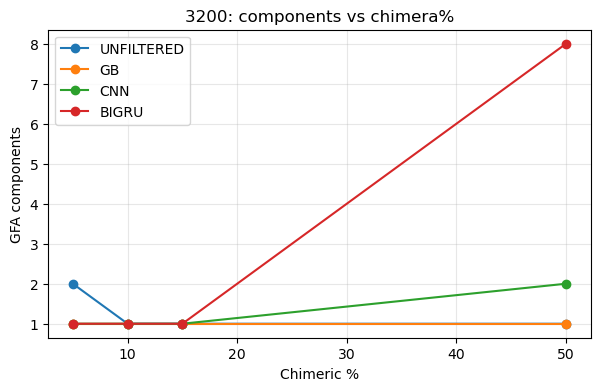

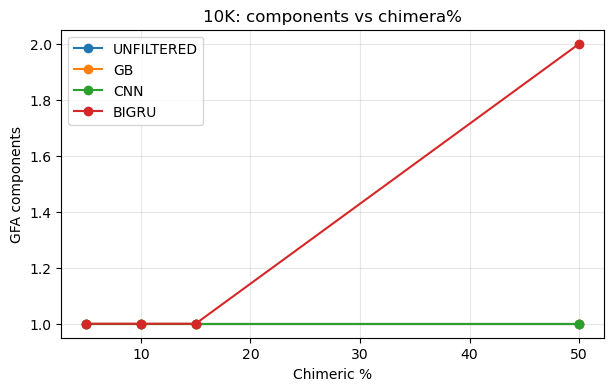

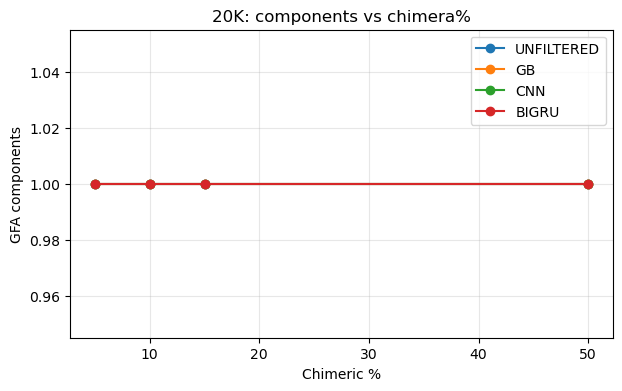

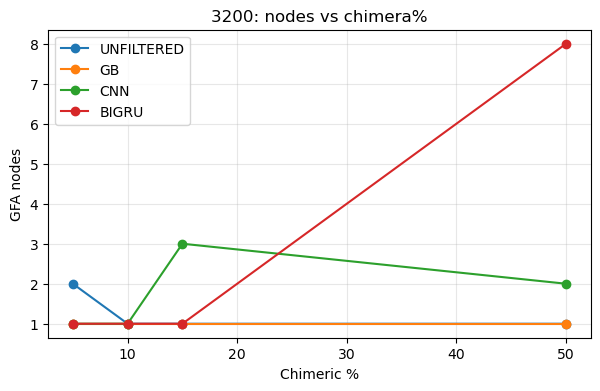

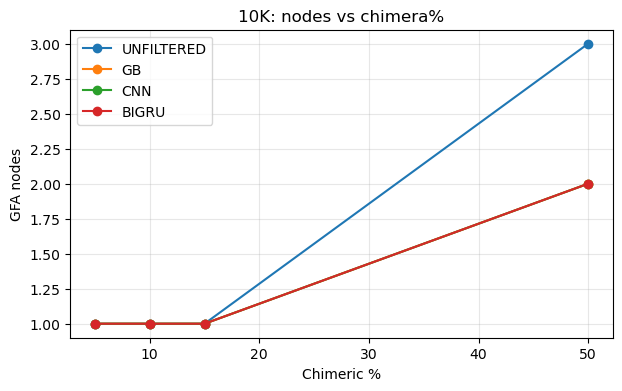

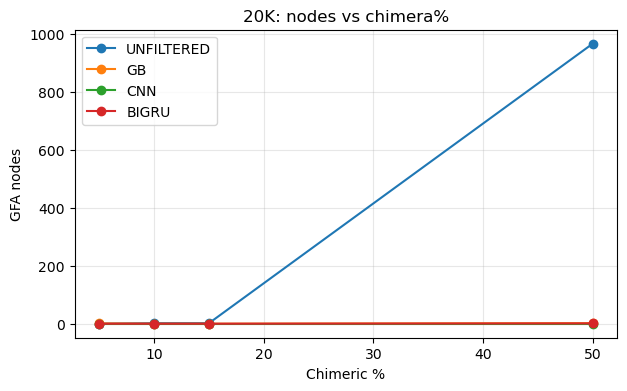

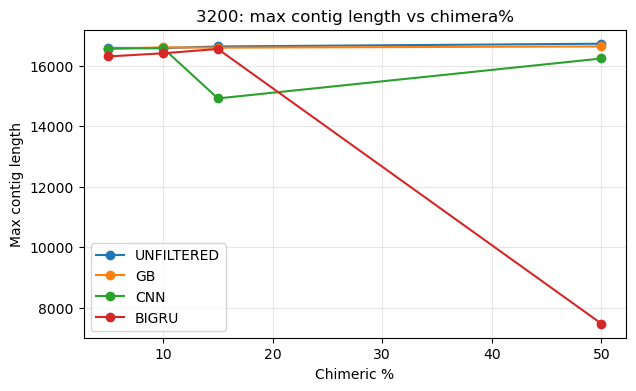

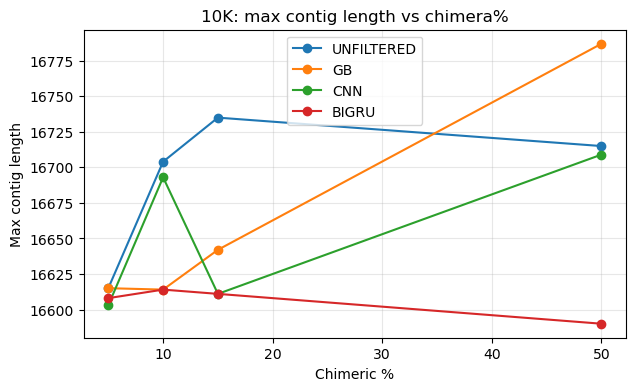

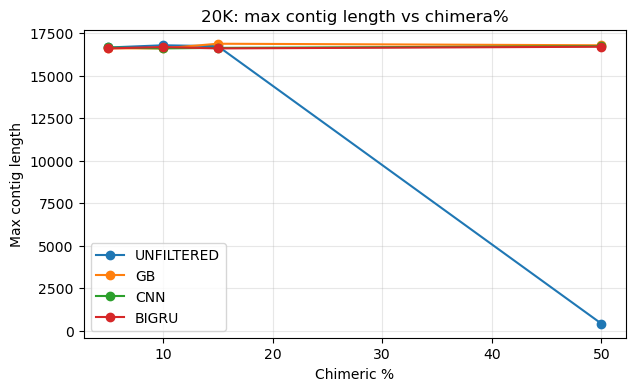

In [91]:
plot_df = dfd[dfd["model"].isin(["UNFILTERED", "GB", "CNN", "BIGRU"])].copy()
model_order = ["UNFILTERED", "GB", "CNN", "BIGRU"]

def plot_metric(metric, ylabel, title_suffix):
    for rl in ["3200", "10K", "20K"]:
        d = plot_df[plot_df["read_level"] == rl].sort_values("chimera_pct")
        if d.empty:
            continue

        plt.figure(figsize=(7, 4))
        for m in model_order:
            dm = d[d["model"] == m]
            if dm.empty:
                continue
            plt.plot(dm["chimera_pct"], dm[metric], marker="o", label=m)

        plt.xlabel("Chimeric %")
        plt.ylabel(ylabel)
        plt.title(f"{rl}: {title_suffix}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

plot_metric("gfa_components", "GFA components", "components vs chimera%")
plot_metric("gfa_nodes", "GFA nodes", "nodes vs chimera%")
plot_metric("spades_max_len", "Max contig length", "max contig length vs chimera%")

In [92]:
out_dir = root / "reports"
final_tbl.to_csv(out_dir / "final_metrics_with_nodes.tsv", sep="\t", index=False)
delta_tbl.to_csv(out_dir / "final_deltas_vs_unfiltered.tsv", sep="\t", index=False)
best.to_csv(out_dir / "final_best_per_dataset.tsv", sep="\t", index=False)

print("Wrote:")
print("-", out_dir / "final_metrics_with_nodes.tsv")
print("-", out_dir / "final_deltas_vs_unfiltered.tsv")
print("-", out_dir / "final_best_per_dataset.tsv")

Wrote:
- /Users/yvonnelin/Desktop/mitochime/reports/final_metrics_with_nodes.tsv
- /Users/yvonnelin/Desktop/mitochime/reports/final_deltas_vs_unfiltered.tsv
- /Users/yvonnelin/Desktop/mitochime/reports/final_best_per_dataset.tsv
